<a href="https://colab.research.google.com/github/SURITIBHUNIA-MCA2024-26-55-UEMK/C_PROGRAM/blob/main/RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

sns.set(style='whitegrid')

print('Libraries imported and setup complete.')

Libraries imported and setup complete.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iot_blockchain_security_dataset.csv to iot_blockchain_security_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('iot_blockchain_security_dataset.csv')
print(df.shape)
df.head()

(1000, 11)


,Device ID,IoT Layer,Request Type,Data Size (KB),Processing Time (ms),Security Threat Type,Attack Severity (0-10),Blockchain Transaction Time (ms),Consensus Mechanism,Energy Consumption (mJ),Threat Mitigated
0,D0001,Application,Data Transmission,552,42,DDoS,1,142,PBFT,1.26,1
1,D0002,Application,Data Transmission,704,24,DDoS,1,197,PoS,0.66,0
2,D0003,Device,Authentication,485,35,Eavesdropping,7,272,PoS,0.92,0
3,D0004,Application,Data Transmission,965,21,Eavesdropping,1,187,PoS,1.88,0
4,D0005,Device,Encrypted Data Transfer,653,17,Tampering,1,155,PoS,1.80,1


In [ ]:
# Check for missing values and data types
print('Missing values per column:')
print(df.isnull().sum())

print('\nData types:')
print(df.dtypes)

# If any cleaning is required (e.g., trimming whitespace or renaming columns), do it here
# For example, ensuring column names are stripped:
df.columns = [col.strip() for col in df.columns]

# Verify changes
print('\nCleaned column names:')
print(df.columns.tolist())

Missing values per column:
Device ID                           0
IoT Layer                           0
Request Type                        0
Data Size (KB)                      0
Processing Time (ms)                0
Security Threat Type                0
Attack Severity (0-10)              0
Blockchain Transaction Time (ms)    0
Consensus Mechanism                 0
Energy Consumption (mJ)             0
Threat Mitigated                    0
dtype: int64

Data types:
Device ID                            object
IoT Layer                            object
Request Type                         object
Data Size (KB)                        int64
Processing Time (ms)                  int64
Security Threat Type                 object
Attack Severity (0-10)                int64
Blockchain Transaction Time (ms)      int64
Consensus Mechanism                  object
Energy Consumption (mJ)             float64
Threat Mitigated                      int64
dtype: object

Cleaned column names:
['Device

Numeric Columns: ['Data Size (KB)', 'Processing Time (ms)', 'Attack Severity (0-10)', 'Blockchain Transaction Time (ms)', 'Energy Consumption (mJ)', 'Threat Mitigated']


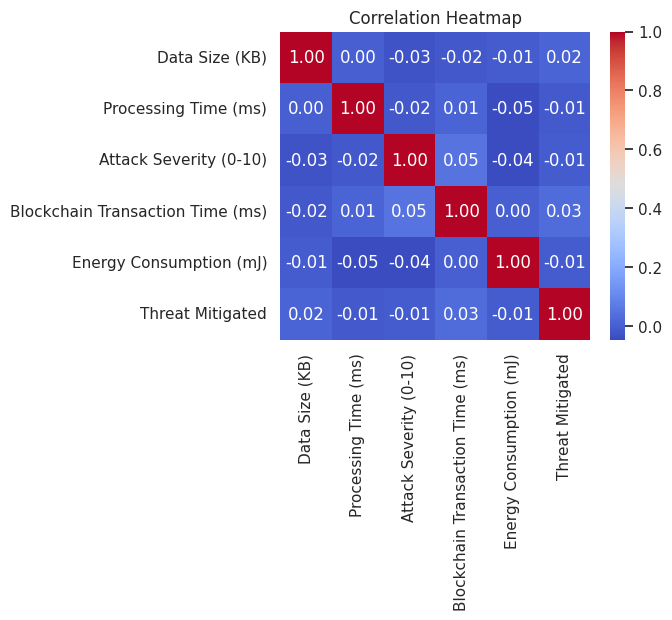

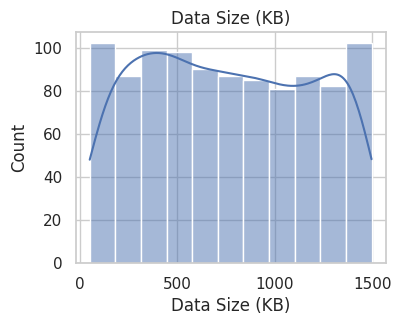

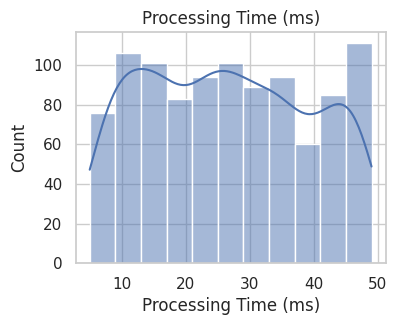

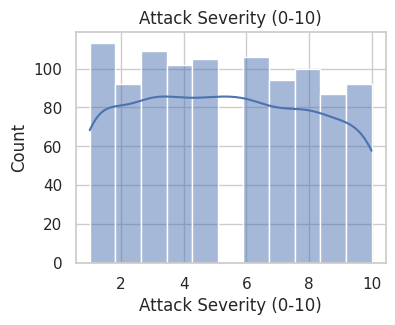

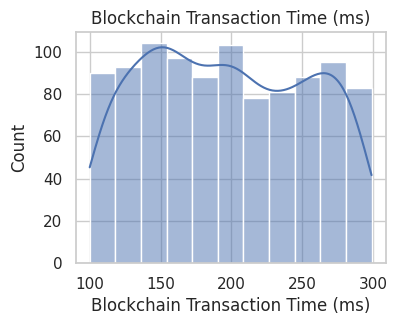

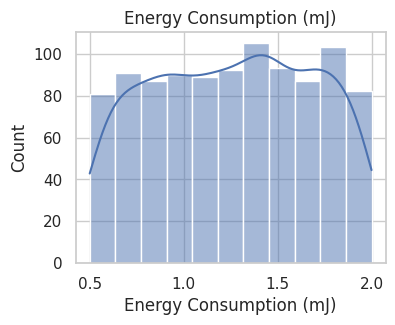

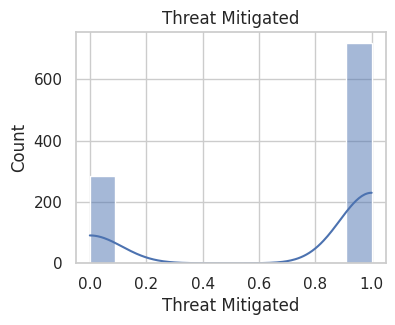

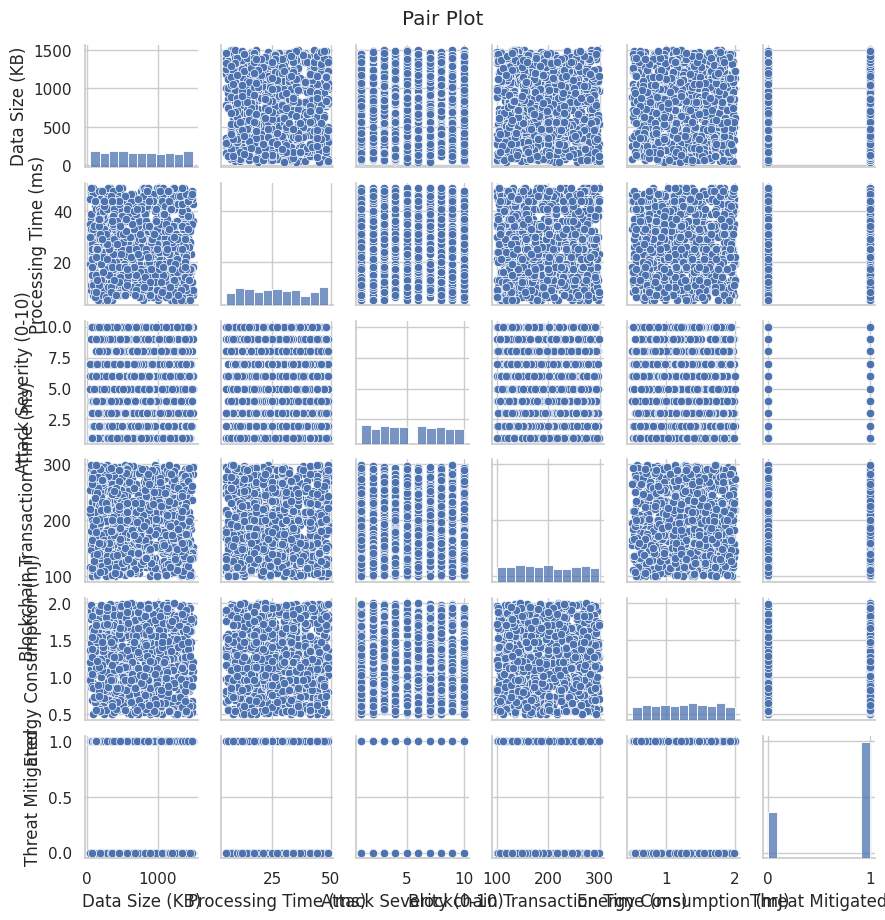

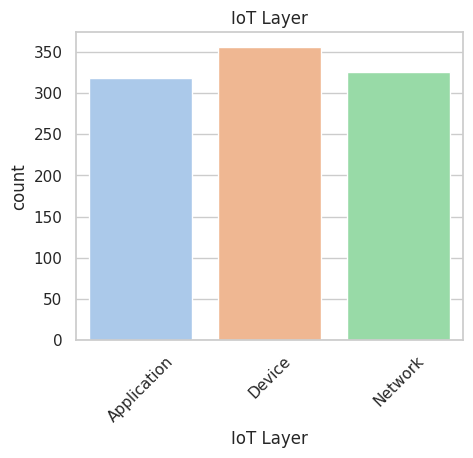

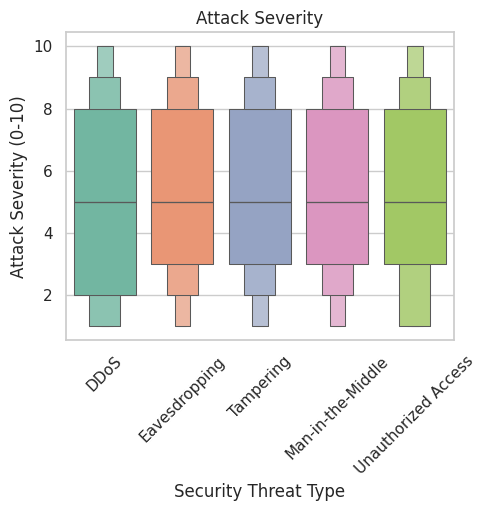

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
print('Numeric Columns:', numeric_df.columns.tolist())

# Heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(5, 4))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

# Histograms
numeric_cols = numeric_df.columns
for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col}')
    plt.show()

# Pairplot (smaller)
if len(numeric_cols) >= 2:
    sns.pairplot(df[list(numeric_cols)], height=1.5)
    plt.suptitle('Pair Plot', y=1.02)
    plt.show()

# Count plot
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='IoT Layer', palette='pastel')
plt.xticks(rotation=45)
plt.title('IoT Layer')
plt.show()

# Boxen plot
plt.figure(figsize=(5, 4))
sns.boxenplot(x='Security Threat Type', y='Attack Severity (0-10)', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Attack Severity')
plt.show()

Numeric features: ['Data Size (KB)', 'Processing Time (ms)', 'Attack Severity (0-10)', 'Blockchain Transaction Time (ms)', 'Energy Consumption (mJ)']
Categorical features: ['Device ID', 'IoT Layer', 'Request Type', 'Security Threat Type', 'Consensus Mechanism']
Prediction Accuracy: 0.8


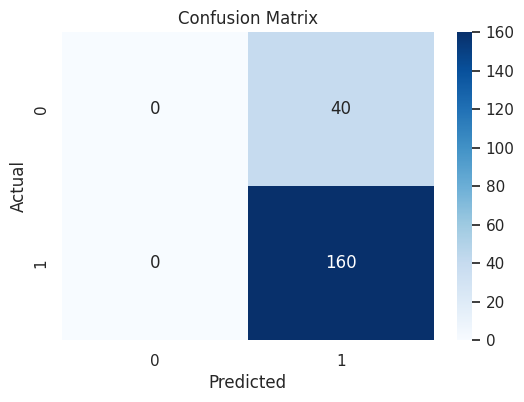

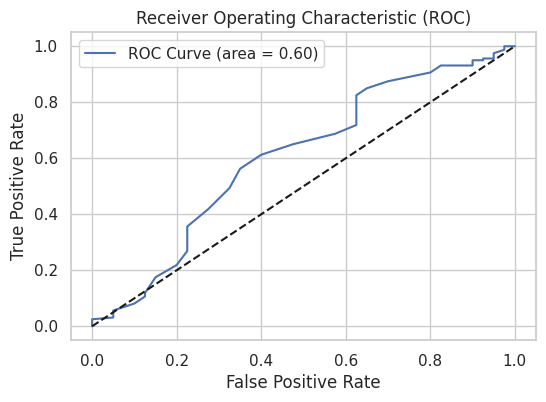

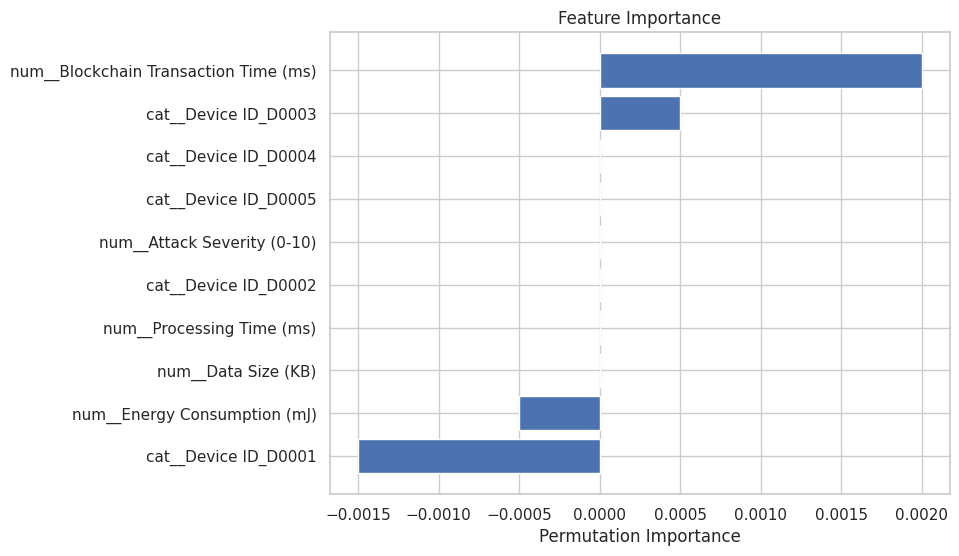

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the target and feature set
target = 'Threat Mitigated'

# Use all other columns as features except the target
features = df.columns.drop(target)

# Separate features into numerical and categorical
numeric_features = df[features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df[features].select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

# Create a preprocessing pipeline for categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline with preprocessing and model training using RandomForestClassifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Split the data into training and test sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model accuracy
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
try:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='best')
    plt.show()
except Exception as e:
    print(f'ROC curve could not be generated: {e}')

# Permutation Importance
result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx])
plt.yticks(range(len(sorted_idx)), np.array(pipeline.named_steps['preprocessor'].get_feature_names_out())[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.show()